In [1]:
%matplotlib inline

import os
import sys
import copy
import warnings

import torch
import numpy as np

import matplotlib.pyplot as plt

from pathlib import Path

sys.path.append('../../../')

%load_ext autoreload
%autoreload 2

from computer_vision.yolov11_pose.parameter_parser import parser
from computer_vision.yolov11_pose.nn.tasks import PoseModel
from computer_vision.yolov11_pose.utils.metrics import DetMetrics, PoseMetrics, box_iou
from computer_vision.yolov11_pose.utils.checks import check_imgsz
from computer_vision.yolov11_pose.data.utils import check_det_dataset
from computer_vision.yolov11_pose.data.build import build_yolo_dataset, build_dataloader
from computer_vision.yolov11_pose.cfg import get_cfg
from computer_vision.yolov11_pose.utils.torch_utils import unwrap_model
from computer_vision.yolov11_pose.utils.nms import non_max_suppression # for post processing
from computer_vision.yolov11_pose.utils.ops import xywh2xyxy, xyxy2xywh
from computer_vision.yolov11_pose.utils.metrics import bbox_iou

In [2]:
main_dirpath='D:/results/yolov11_pose'
checkpoint_dirpath=os.path.join(main_dirpath, 'predict')
output_dirpath=os.path.join(main_dirpath, 'validation')
args=parser.parse_args(f'--save-dir {output_dirpath} --data ../coco-pose.yaml --visualize'.split())


task='pose'
if task=='pose':
    data_dirpath='D:/data/ultralytics/coco-pose/images/train2017'
    data_config='../coco-pose.yaml'
elif task=='detect':
    data_dirpath='D:/data/ultralytics/coco/images/val2017'
    data_config='../coco.yaml'
elif task=='segment':
    data_dirpath='D:/data/ultralytics/coco8-seg/images/val'
    data_config='../coco8-seg.yaml'



hyp=get_cfg()
dataset=build_yolo_dataset(args=args, cfg=hyp, task=task, img_path=data_dirpath, batch=args.batch_size or hyp.batch, 
                   data=data_config,  mode='train', rect=False, stride=32, channels=3)
for i in range(4): print(dataset.labels[i]['cls'].shape)
dataloader=build_dataloader(dataset, batch=hyp.batch, workers=1, shuffle=True, drop_last=True, pin_memory=True)


In data.build.build_yolo_dataset batch 16
In data.dataset.YOLODataset.get_labels cache_path D:\data\ultralytics\coco-pose\labels\train2017.cache
Scanning D:\data\ultralytics\coco-pose\labels\train2017.cache... 56599 images, 61688 backgrounds, 0 corrupts
In data.dataset.YOLODataset.__init__ augment True rect False
(0, 1)
(0, 1)
(0, 1)
(0, 1)
In data.build.build_dataloader batch 16


In [3]:
cfg='../yolo11-pose.yaml'
model=PoseModel(cfg=cfg,nc=1,verbose=True)
model.fuse(); # we need to call `fuse` so we can successfully load pretrained weight
checkpoint_file=os.path.join(checkpoint_dirpath, 'yolo11n_torch.pt')
assert os.path.isfile(checkpoint_file), f'{checkpoint_file} does not exist'
checkpoint=torch.load(checkpoint_file, weights_only=False)
try:
    model.load_state_dict(checkpoint['model'])
except RuntimeError as err:
    state_dict=copy.deepcopy(model.state_dict())
    for name, params in checkpoint['model'].items():
        name=name[len('model.'):] # each parameter name is model.model.xxx so we need to remove 1 model.
        
        if name not in state_dict or params.shape!=state_dict[name].shape:
            print(name, name in state_dict, (params.shape,state_dict[name].shape) if name in state_dict else None)
        else: state_dict[name]=params
    model.load_state_dict(state_dict)

model.train()

In nn.tasks.PoseModel.__init__ type(cfg) <class 'str'>, cfg ../yolo11-pose.yaml
In nn.tasks.parse_model d {'nc': 1, 'kpt_shape': [17, 3], 'scales': {'n': [0.5, 0.25, 1024], 's': [0.5, 0.5, 1024], 'm': [0.5, 1.0, 512], 'l': [1.0, 1.0, 512], 'x': [1.0, 1.5, 512]}, 'backbone': [[-1, 1, 'Conv', [64, 3, 2]], [-1, 1, 'Conv', [128, 3, 2]], [-1, 2, 'C3k2', [256, False, 0.25]], [-1, 1, 'Conv', [256, 3, 2]], [-1, 2, 'C3k2', [512, False, 0.25]], [-1, 1, 'Conv', [512, 3, 2]], [-1, 2, 'C3k2', [512, True]], [-1, 1, 'Conv', [1024, 3, 2]], [-1, 2, 'C3k2', [1024, True]], [-1, 1, 'SPPF', [1024, 5]], [-1, 2, 'C2PSA', [1024]]], 'head': [[-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 6], 1, 'Concat', [1]], [-1, 2, 'C3k2', [512, False]], [-1, 1, 'nn.Upsample', ['None', 2, 'nearest']], [[-1, 4], 1, 'Concat', [1]], [-1, 2, 'C3k2', [256, False]], [-1, 1, 'Conv', [256, 3, 2]], [[-1, 13], 1, 'Concat', [1]], [-1, 2, 'C3k2', [512, False]], [-1, 1, 'Conv', [512, 3, 2]], [[-1, 10], 1, 'Concat', [1]], [-1, 2, 

PoseModel(
  (model): Sequential(
    (0): Conv(
      (conv): Conv2d(3, 16, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (1): Conv(
      (conv): Conv2d(16, 32, kernel_size=(3, 3), stride=(2, 2), padding=(1, 1))
      (act): SiLU(inplace=True)
    )
    (2): C3k2(
      (cv1): Conv(
        (conv): Conv2d(32, 32, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (cv2): Conv(
        (conv): Conv2d(48, 64, kernel_size=(1, 1), stride=(1, 1))
        (act): SiLU(inplace=True)
      )
      (m): ModuleList(
        (0): Bottleneck(
          (cv1): Conv(
            (conv): Conv2d(16, 8, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
          (cv2): Conv(
            (conv): Conv2d(8, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
            (act): SiLU(inplace=True)
          )
        )
      )
    )
    (3): Conv(
      (conv): Conv2d(64, 64, 

In [4]:
model.args=hyp

batch=next(iter(dataloader))
print({k:(v.shape if isinstance(v, torch.Tensor) else v) for k, v in batch.items()})

{'batch_idx': torch.Size([38]), 'bboxes': torch.Size([38, 4]), 'cls': torch.Size([38, 1]), 'im_file': ['D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000183233.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000234733.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000018201.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000581326.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000489414.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000410331.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000155997.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000231379.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000572737.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000072628.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000075309.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000494453.jpg', 'D:\\data\\ultralytic

0,1,

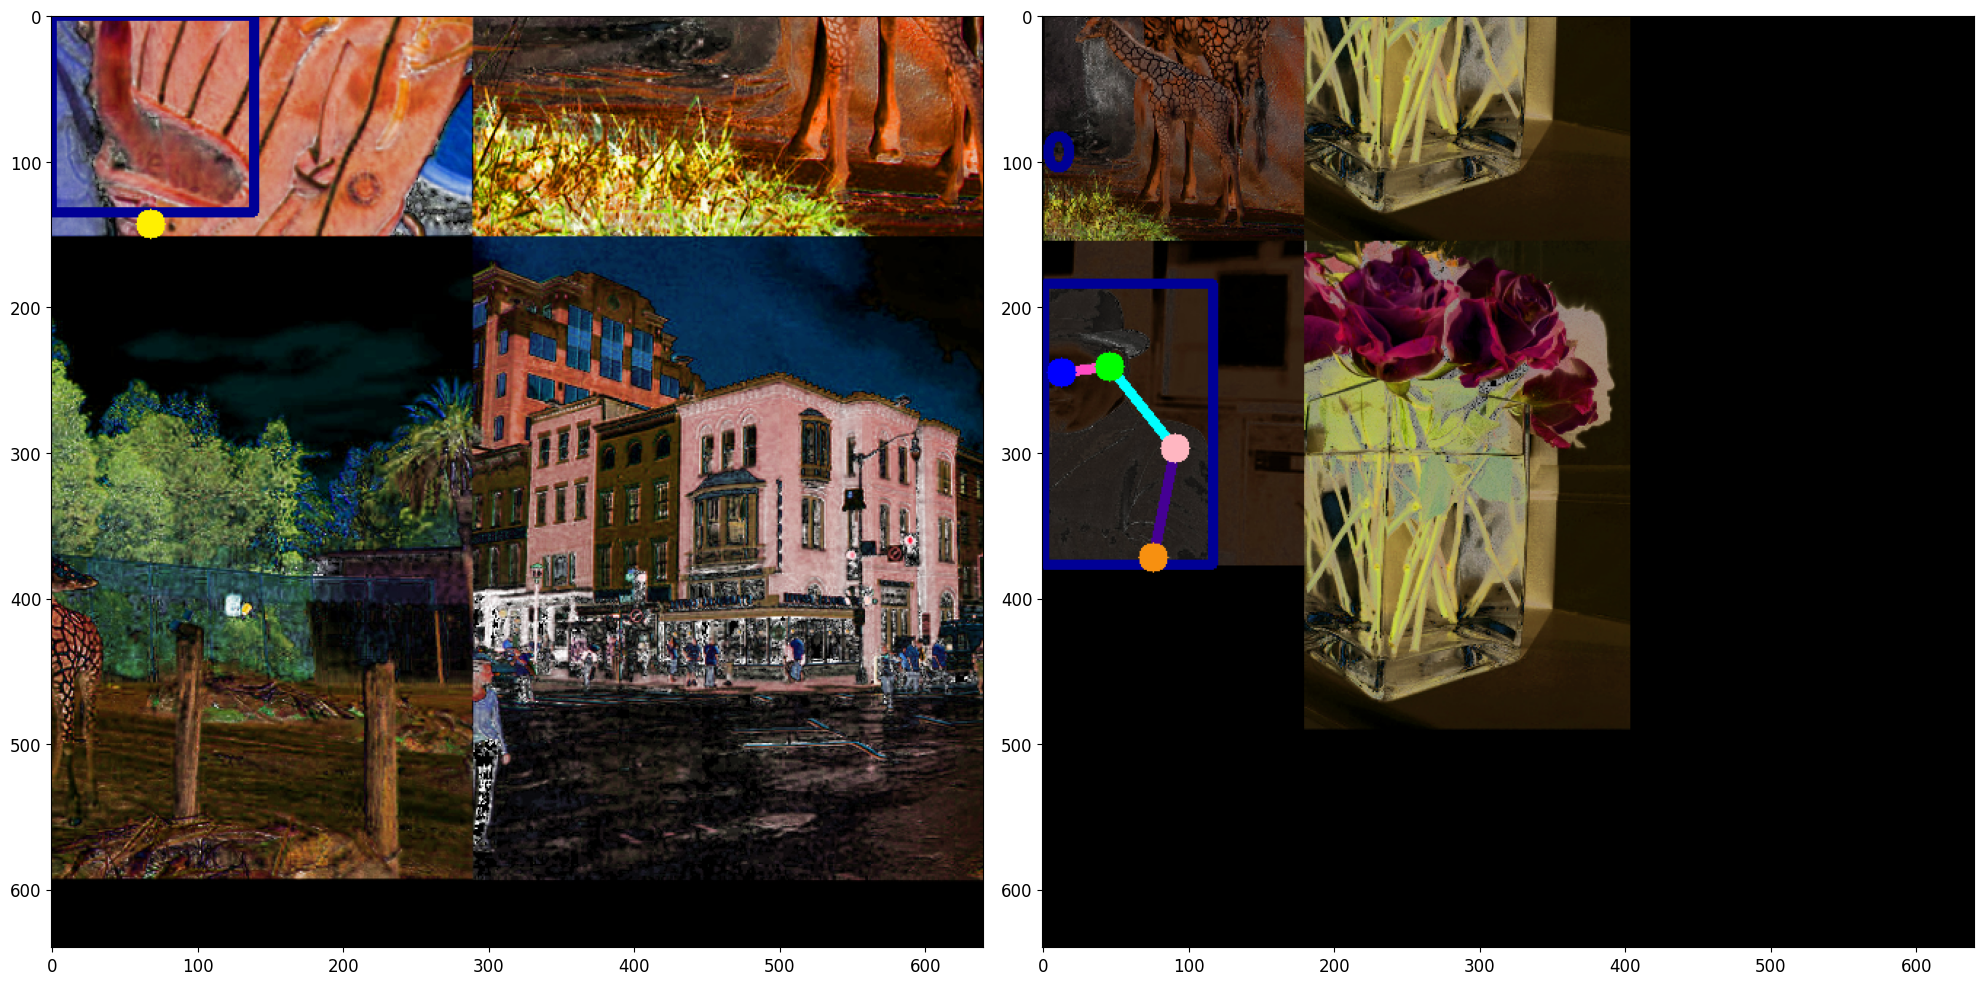

In [5]:
from computer_vision.misc import alpha_bending, instance2mask

from matplotlib import patches
import matplotlib.pyplot as plt
from computer_vision.yolov11_pose.utils.ops import xywh2xyxy
from computer_vision.yolov11_pose.utils.viz import general_skeleton_overlay

cmap = plt.get_cmap('tab10', 10)
plt.rcParams.update({'font.size'   : 12})

n_data=2
ncols=2
nrows=int(np.ceil(n_data/ncols))

_, ax=plt.subplots(nrows,ncols,figsize=(20,20))
for idx, item in enumerate(dataloader):
    if idx==n_data: break
    print(idx, end=',')
    batch_idx=item['batch_idx']
    flag=batch_idx==idx

    classes=item['cls'][flag].flatten() # (N,1) to (N,)
    classes=[f'{int(c)}' for c in classes]
    img=item['img'][idx] # (C,H,W)
    height, width=img.shape[-2:]
    if isinstance(img, torch.Tensor):
        img=img.permute(1,2,0).contiguous().numpy() # HxWxC
        img=img[...,::-1] # RGB to BGR

    bboxes=item['bboxes'][flag].clone()
    bboxes=xywh2xyxy(bboxes)
    # denormalize bboxes
    bboxes[...,[0,2]]*=width
    bboxes[...,[1,3]]*=height
    bboxes=bboxes.numpy()
    
    keypoints=item['keypoints'][flag].clone() if 'keypoints' in item else None # NxMx3
    if keypoints is not None: # denormalized
        keypoints[...,0]*=width
        keypoints[...,1]*=height
        keypoints=keypoints.numpy()
    if keypoints is not None:
        img=general_skeleton_overlay(img_bgr=img, class_names=classes, bboxes=bboxes, keypoints=keypoints)
        ax[idx].imshow(img[...,::-1])
    else: ax[idx].imshow(img[...,::-1])
    if keypoints is None:
        for j, (box,cls) in enumerate(zip(bboxes, classes)):
            # Create a Rectangle patch
            rect = patches.Rectangle(box[:2], box[2]-box[0], box[3]-box[1], linewidth=2, edgecolor=cmap(j), facecolor='none')
            # Add the patch to the Axes
            ax[idx].add_patch(rect)
            ax[idx].text(*box[:2], f'{cls}', color=cmap(j), fontsize=12)

plt.tight_layout()


In [7]:
batch=copy.deepcopy(item)
print({k:(v.shape if isinstance(v, torch.Tensor) else v) for k, v in batch.items()})

# preprocess batch
batch["img"] = batch["img"].float() / 255

# since batch is dict model.forward internally calls loss function
# the loss function checks whether criterion was defined;if not, defined it
# then call forward model on image and call criterion on preds and batch

# here is from loss function in model class
preds=None
if getattr(model, "criterion", None) is None: model.criterion=model.init_criterion()
if preds is None: preds=model(batch['img'])

print('preds ', type(preds), len(preds))
print('preds[0] ', type(preds[0]), len(preds[0]), [x.shape for x in preds[0]])
print('preds[1] ', type(preds[1]), preds[1].shape)
print('model.criterion.no ', model.criterion.no)
loss, loss_items=model.criterion(preds, batch) # which in turn, calls loss.loss(.)
print('loss ', loss,  ' loss_items ', loss_items)

{'batch_idx': torch.Size([7]), 'bboxes': torch.Size([7, 4]), 'cls': torch.Size([7, 1]), 'im_file': ['D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000210635.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000318044.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000504152.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000042849.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000215081.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000543393.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000331324.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000115912.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000048548.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000147000.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000343852.jpg', 'D:\\data\\ultralytics\\coco-pose\\images\\train2017\\000000196981.jpg', 'D:\\data\\ultralytics\\